이론 상 필요한 최소 저차원 (d): 5326


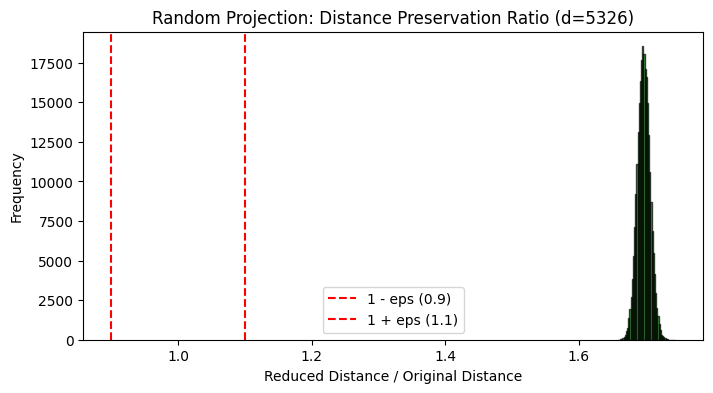

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.random_projection import GaussianRandomProjection, johnson_lindenstrauss_min_dim
from sklearn.metrics import pairwise_distances

np.random.seed(42)

# 1. JL Lemma에 따른 이론적 최소 차원 계산 (샘플 수 500, 오차 10%)
n_samples = 500
eps = 0.1
min_dim = johnson_lindenstrauss_min_dim(n_samples=n_samples, eps=eps)
print(f"이론 상 필요한 최소 저차원 (d): {min_dim}")

# 2. 10,000차원의 가상 고차원 데이터 생성
X_high = np.random.randn(n_samples, 10000)
orig_distances = pairwise_distances(X_high)

# 3. 랜덤 투영 실행
grp = GaussianRandomProjection(n_components=min_dim, random_state=42)
X_reduced = grp.fit_transform(X_high)
reduced_distances = pairwise_distances(X_reduced)

# 4. 거리 보존 비율 계산 (거리가 1 +- eps 내에 들어오는지)
# 0 분모 제외를 위해 마스킹
original_flat = orig_distances[orig_distances > 0]
reduced_flat = reduced_distances[orig_distances > 0]
ratio = reduced_flat / original_flat

# 5. 시각화
plt.figure(figsize=(8, 4))
plt.hist(ratio, bins=50, color='g', alpha=0.7, edgecolor='black')
plt.axvline(1 - eps, color='r', linestyle='--', label=f'1 - eps ({1-eps:.1f})')
plt.axvline(1 + eps, color='r', linestyle='--', label=f'1 + eps ({1+eps:.1f})')
plt.title(f"Random Projection: Distance Preservation Ratio (d={min_dim})")
plt.xlabel("Reduced Distance / Original Distance")
plt.ylabel("Frequency")
plt.legend()
plt.show()